# Stage A — Bias-correction validation

Validates the CDF / linear corrections trained by `run_collocate.py train` against the
expectations laid out for Ahn-2021-style quantile mapping. Inputs are exactly the
artifacts `train` already wrote:

  * `COLLOCATE_DIR/{sensor}_{site}.csv` — matched (satellite, AERONET) pairs
  * `BIASC_DIR/{sensor}_{region}_{season}.pkl` — fitted `CDFCorrection`

**Checks (per `sensor × region × season` stratum):**

| # | What | Pass criterion | Why it matters |
|---|---|---|---|
| 1 | MBE after | `|MBE_after| < 0.02` | Headline — if MBE doesn't move to ~0, the correction isn't working. |
| 2 | RMSE drop | 20–40% reduction typical | Bias term killed, variance unchanged. >60% drop ⇒ likely overfit. |
| 3 | Pearson R | Δ ≤ ±0.10 | CDF mapping is monotonic; R should barely move. Big jump ⇒ bug. |
| 4 | Spearman ρ | Δ ≈ 0 (within ties) | Mathematically invariant under monotonic transforms. |
| 5 | CV vs in-sample RMSE | `RMSE_cv / RMSE_in < 1.5` | Large inflation ⇒ transfer function overfits training quantiles. |
| 6 | CDF overlay | Corrected ≈ AERONET visually | Ahn 2021 Fig. 3 sanity check. |

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from config import COLLOCATE_DIR, BIASC_DIR
from bias_correction import load_all_corrections

SENSORS = ('himawari_l2', 'himawari_l3', 'viirs_snpp', 'viirs_noaa20', 'modis_maiac')

# Validation thresholds
MBE_TOL          = 0.02
RMSE_DROP_MIN    = 0.20   # at least 20% RMSE reduction expected
RMSE_DROP_MAX    = 0.60   # >60% reduction is suspicious
PEARSON_DELTA    = 0.10
SPEARMAN_DELTA   = 0.02
CV_INFLATION_MAX = 1.50

print('Collocate dir :', COLLOCATE_DIR)
print('Bias-corr dir :', BIASC_DIR)

Collocate dir : /home/slow_data/Air_Quality/Stage_A/collocated
Bias-corr dir : /home/slow_data/Air_Quality/Stage_A/bias_corr


## 1. Load matched pairs + trained corrections, apply

In [2]:
csv_files = sorted(Path(COLLOCATE_DIR).glob('*.csv'))
df = pd.concat([pd.read_csv(p) for p in csv_files], ignore_index=True)
df = df[df['sensor'].isin(SENSORS)].copy()

corrections = load_all_corrections(list(SENSORS), BIASC_DIR)

df['sat_corrected'] = np.nan
for (s, reg, sea), c in corrections.items():
    m = (df['sensor'] == s) & (df['region'] == reg) & (df['season'] == sea)
    if m.any():
        df.loc[m, 'sat_corrected'] = c.apply(
            df.loc[m, 'satellite_aod'].values.astype(float))

print(f'Loaded {len(csv_files)} CSV(s) — {len(df):,} pairs')
print(f'Trained strata: {len(corrections)}  '
      f'({sum(1 for c in corrections.values() if c.correction_type != "none")} usable, '
      f'{sum(1 for c in corrections.values() if c.correction_type == "none")} rejected)')

Loaded 10 CSV(s) — 6,161 pairs
Trained strata: 20  (16 usable, 4 rejected)


## 2. Per-stratum metrics — before vs after

For each `(sensor, region, season)` stratum we compute pre- and post-correction
MBE, RMSE, Pearson R, Spearman ρ. CV RMSE is read off the fitted `CDFCorrection`
(5-fold, computed in `bias_correction.py` `_compute_cv_rmse`).

In [3]:
def _r(x, y):
    if len(x) < 5:
        return np.nan
    try:
        return float(pearsonr(x, y)[0])
    except Exception:
        return np.nan

def _rho(x, y):
    if len(x) < 5:
        return np.nan
    try:
        return float(spearmanr(x, y).correlation)
    except Exception:
        return np.nan

def stratum_metrics(sub):
    sat = sub['satellite_aod'].values.astype(float)
    aer = sub['aeronet_aod'].values.astype(float)
    cor = sub['sat_corrected'].values.astype(float)
    m = np.isfinite(sat) & np.isfinite(aer) & np.isfinite(cor)
    sat, aer, cor = sat[m], aer[m], cor[m]
    if len(sat) < 5:
        return None
    return {
        'N':           int(len(sat)),
        'MBE_before':  float(np.mean(sat - aer)),
        'MBE_after':   float(np.mean(cor - aer)),
        'RMSE_before': float(np.sqrt(np.mean((sat - aer) ** 2))),
        'RMSE_after':  float(np.sqrt(np.mean((cor - aer) ** 2))),
        'R_before':    _r(sat, aer),
        'R_after':     _r(cor, aer),
        'rho_before':  _rho(sat, aer),
        'rho_after':   _rho(cor, aer),
    }

rows = []
for (s, reg, sea), c in sorted(corrections.items()):
    sub = df[(df['sensor'] == s) & (df['region'] == reg) & (df['season'] == sea)]
    m = stratum_metrics(sub)
    if m is None:
        continue
    m.update({'sensor': s, 'region': reg, 'season': sea,
              'type': c.correction_type,
              'RMSE_cv': float(getattr(c, 'rmse_after_cv', np.nan))})
    rows.append(m)

metrics = (pd.DataFrame(rows)
             .set_index(['sensor', 'region', 'season'])
             .sort_index())
metrics['dRMSE_pct'] = 100 * (metrics['RMSE_before'] - metrics['RMSE_after']) / metrics['RMSE_before']
metrics['dR']        = metrics['R_after']   - metrics['R_before']
metrics['drho']      = metrics['rho_after'] - metrics['rho_before']
metrics['CV_infl']   = metrics['RMSE_cv']   / metrics['RMSE_after']
metrics.round(3)

N  MBE_before  MBE_after  RMSE_before  \
sensor       region season                                             
himawari_l2  north  dry     1216      -0.246     -0.013        0.466   
                    wet      561      -0.152     -0.004        0.301   
             south  dry     1537       0.061      0.031        0.265   
                    wet      264       0.066      0.066        0.291   
himawari_l3  north  dry      116      -0.140     -0.001        0.510   
                    wet      109       0.059     -0.000        0.295   
             south  dry      174       0.091      0.020        0.264   
                    wet      101       0.282      0.282        0.402   
modis_maiac  north  dry      301      -0.296     -0.036        0.508   
                    wet      186      -0.252     -0.004        0.419   
             south  dry      599      -0.018      0.219        0.158   
                    wet      181       0.135      0.135        0.165   
viirs_noaa20 north  dry      161       0.017     -0.006        0.249   
                    wet       43      -0.106      0.000        0.239   
             south  dry      171       0.099     -0.001        0.162   
                    wet       35       0.088      0.088        0.121   
viirs_snpp   north  dry      159      -0.017     -0.002        0.303   
                    wet       37      -0.035     -0.000        0.117   
             south  dry      169       0.129      0.005        0.198   
                    wet       41       0.116      0.000        0.131   

                            RMSE_after  R_before  R_after  rho_before  \
sensor       region season                                              
himawari_l2  north  dry          0.422     0.790    0.783       0.830   
                    wet          0.240     0.669    0.653       0.565   
             south  dry          0.233     0.834    0.823       0.704   
                    wet          0.291     0.147    0.147       0.356   
himawari_l3  north  dry          0.564     0.448    0.406       0.522   
                    wet          0.258     0.530    0.569       0.482   
             south  dry          0.205     0.524    0.567       0.466   
                    wet          0.402     0.221    0.221       0.289   
modis_maiac  north  dry          0.429     0.748    0.739       0.710   
                    wet          0.403     0.363    0.328       0.248   
             south  dry          3.805     0.479    0.396       0.494   
                    wet          0.165     0.230    0.230       0.376   
viirs_noaa20 north  dry          0.221     0.926    0.933       0.933   
                    wet          0.195     0.584    0.584       0.204   
             south  dry          0.112     0.856    0.896       0.691   
                    wet          0.121     0.590    0.590       0.423   
viirs_snpp   north  dry          0.306     0.840    0.841       0.902   
                    wet          0.100     0.863    0.863       0.756   
             south  dry          0.141     0.792    0.814       0.801   
                    wet          0.035     0.741    0.741       0.507   

                            rho_after         type  RMSE_cv  dRMSE_pct     dR  \
sensor       region season                                                      
himawari_l2  north  dry         0.807          cdf    0.395      9.457 -0.008   
                    wet         0.555          cdf    0.242     20.271 -0.015   
             south  dry         0.704  cdf_clipped    0.152     12.228 -0.011   
                    wet         0.356         none      NaN      0.000  0.000   
himawari_l3  north  dry         0.522          cdf    0.559    -10.573 -0.042   
                    wet         0.482          cdf    0.275     12.703  0.039   
             south  dry         0.466  cdf_clipped    0.212     22.381  0.044   
                    wet         0.289         none      NaN      0.000  0.000   
modis_maiac  north  dry      

## 3. Pass / fail flags

In [4]:
def flags(row):
    if row['type'] == 'none':
        return '— (rejected at fit)'
    out = []
    if abs(row['MBE_after']) >= MBE_TOL:
        out.append(f'|MBE|={abs(row["MBE_after"]):.3f}≥{MBE_TOL}')
    drop = row['dRMSE_pct'] / 100
    if drop < RMSE_DROP_MIN:
        out.append(f'ΔRMSE={drop*100:+.0f}% small')
    if drop > RMSE_DROP_MAX:
        out.append(f'ΔRMSE={drop*100:+.0f}% overfit?')
    if np.isfinite(row['dR']) and abs(row['dR']) > PEARSON_DELTA:
        out.append(f'ΔR={row["dR"]:+.2f}')
    if np.isfinite(row['drho']) and abs(row['drho']) > SPEARMAN_DELTA:
        out.append(f'Δρ={row["drho"]:+.2f}')
    if np.isfinite(row['CV_infl']) and row['CV_infl'] > CV_INFLATION_MAX:
        out.append(f'CV/in={row["CV_infl"]:.2f}')
    return 'OK' if not out else '; '.join(out)

metrics['status'] = metrics.apply(flags, axis=1)

cols = ['type', 'N',
        'MBE_before', 'MBE_after',
        'RMSE_before', 'RMSE_after', 'RMSE_cv', 'dRMSE_pct',
        'R_before', 'R_after', 'rho_before', 'rho_after',
        'CV_infl', 'status']
metrics[cols].round(3)

type     N  MBE_before  MBE_after  \
sensor       region season                                             
himawari_l2  north  dry             cdf  1216      -0.246     -0.013   
                    wet             cdf   561      -0.152     -0.004   
             south  dry     cdf_clipped  1537       0.061      0.031   
                    wet            none   264       0.066      0.066   
himawari_l3  north  dry             cdf   116      -0.140     -0.001   
                    wet             cdf   109       0.059     -0.000   
             south  dry     cdf_clipped   174       0.091      0.020   
                    wet            none   101       0.282      0.282   
modis_maiac  north  dry     cdf_clipped   301      -0.296     -0.036   
                    wet             cdf   186      -0.252     -0.004   
             south  dry             cdf   599      -0.018      0.219   
                    wet            none   181       0.135      0.135   
viirs_noaa20 north  dry             cdf   161       0.017     -0.006   
                    wet          linear    43      -0.106      0.000   
             south  dry             cdf   171       0.099     -0.001   
                    wet            none    35       0.088      0.088   
viirs_snpp   north  dry             cdf   159      -0.017     -0.002   
                    wet          linear    37      -0.035     -0.000   
             south  dry     cdf_clipped   169       0.129      0.005   
                    wet          linear    41       0.116      0.000   

                            RMSE_before  RMSE_after  RMSE_cv  dRMSE_pct  \
sensor       region season                                                
himawari_l2  north  dry           0.466       0.422    0.395      9.457   
                    wet           0.301       0.240    0.242     20.271   
             south  dry           0.265       0.233    0.152     12.228   
                    wet           0.291       0.291      NaN      0.000   
himawari_l3  north  dry           0.510       0.564    0.559    -10.573   
                    wet           0.295       0.258    0.275     12.703   
             south  dry           0.264       0.205    0.212     22.381   
                    wet           0.402       0.402      NaN      0.000   
modis_maiac  north  dry           0.508       0.429    0.436     15.668   
                    wet           0.419       0.403    0.421      3.783   
             south  dry           0.158       3.805    0.305  -2305.147   
                    wet           0.165       0.165      NaN      0.000   
viirs_noaa20 north  dry           0.249       0.221    0.260     11.300   
                    wet           0.239       0.195    0.212     18.341   
             south  dry           0.162       0.112    0.219     31.006   
                    wet           0.121       0.121      NaN      0.000   
viirs_snpp   north  dry           0.303       0.306    0.327     -1.010   
                    wet           0.117       0.100    0.108     14.600   
             south  dry           0.198       0.141    0.149     28.521   
                    wet           0.131       0.035    0.037     73.288   

                            R_before  R_after  rho_before  rho_after  CV_infl  \
sensor       region season                                                      
himawari_l2  north  dry        0.790    0.783       0.830      0.807    0.937   
                    wet        0.669    0.653       0.565      0.555    1.009   
             south  dry        0.834    0.823       0.704      0.704    0.652   
                    wet        0.147    0.147       0.356      0.356      NaN   
himawari_l3  north  dry        0.448    0.406       0.522      0.522    0.991   
                    wet        0.530    0.569       0.482      0.482    1.067   
             south  dry        0.524    0.567       0.466      0.466    1.038   
                    wet        0.221    0.221       0.289      0.289  

In [5]:
# Quick summary
n_total = len(metrics)
n_used  = int((metrics['type'] != 'none').sum())
n_ok    = int((metrics['status'] == 'OK').sum())
print(f'Strata: {n_total} total, {n_used} usable, {n_ok} fully passing all gates')
print()
problem = metrics[(metrics['type'] != 'none') & (metrics['status'] != 'OK')]
if len(problem):
    print(f'{len(problem)} stratum/strata need review:')
    print(problem[['type', 'N', 'MBE_after', 'dRMSE_pct',
                   'dR', 'drho', 'CV_infl', 'status']].round(3).to_string())
else:
    print('All usable strata pass.')

Strata: 20 total, 16 usable, 3 fully passing all gates

13 stratum/strata need review:
                                   type     N  MBE_after  dRMSE_pct     dR   drho  CV_infl                                status
sensor       region season                                                                                                      
himawari_l2  north  dry             cdf  1216     -0.013      9.457 -0.008 -0.023    0.937             ΔRMSE=+9% small; Δρ=-0.02
             south  dry     cdf_clipped  1537      0.031     12.228 -0.011  0.000    0.652    |MBE|=0.031≥0.02; ΔRMSE=+12% small
himawari_l3  north  dry             cdf   116     -0.001    -10.573 -0.042  0.000    0.991                      ΔRMSE=-11% small
                    wet             cdf   109     -0.000     12.703  0.039 -0.000    1.067                      ΔRMSE=+13% small
modis_maiac  north  dry     cdf_clipped   301     -0.036     15.668 -0.009 -0.002    1.016    |MBE|=0.036≥0.02; ΔRMSE=+16% small
          

## 4. Empirical CDF overlay — Ahn 2021 Fig. 3 visual check

Raw satellite (dashed), corrected satellite (solid), AERONET (dotted) on the same
axes. After correction the satellite curve should sit on top of the AERONET curve.

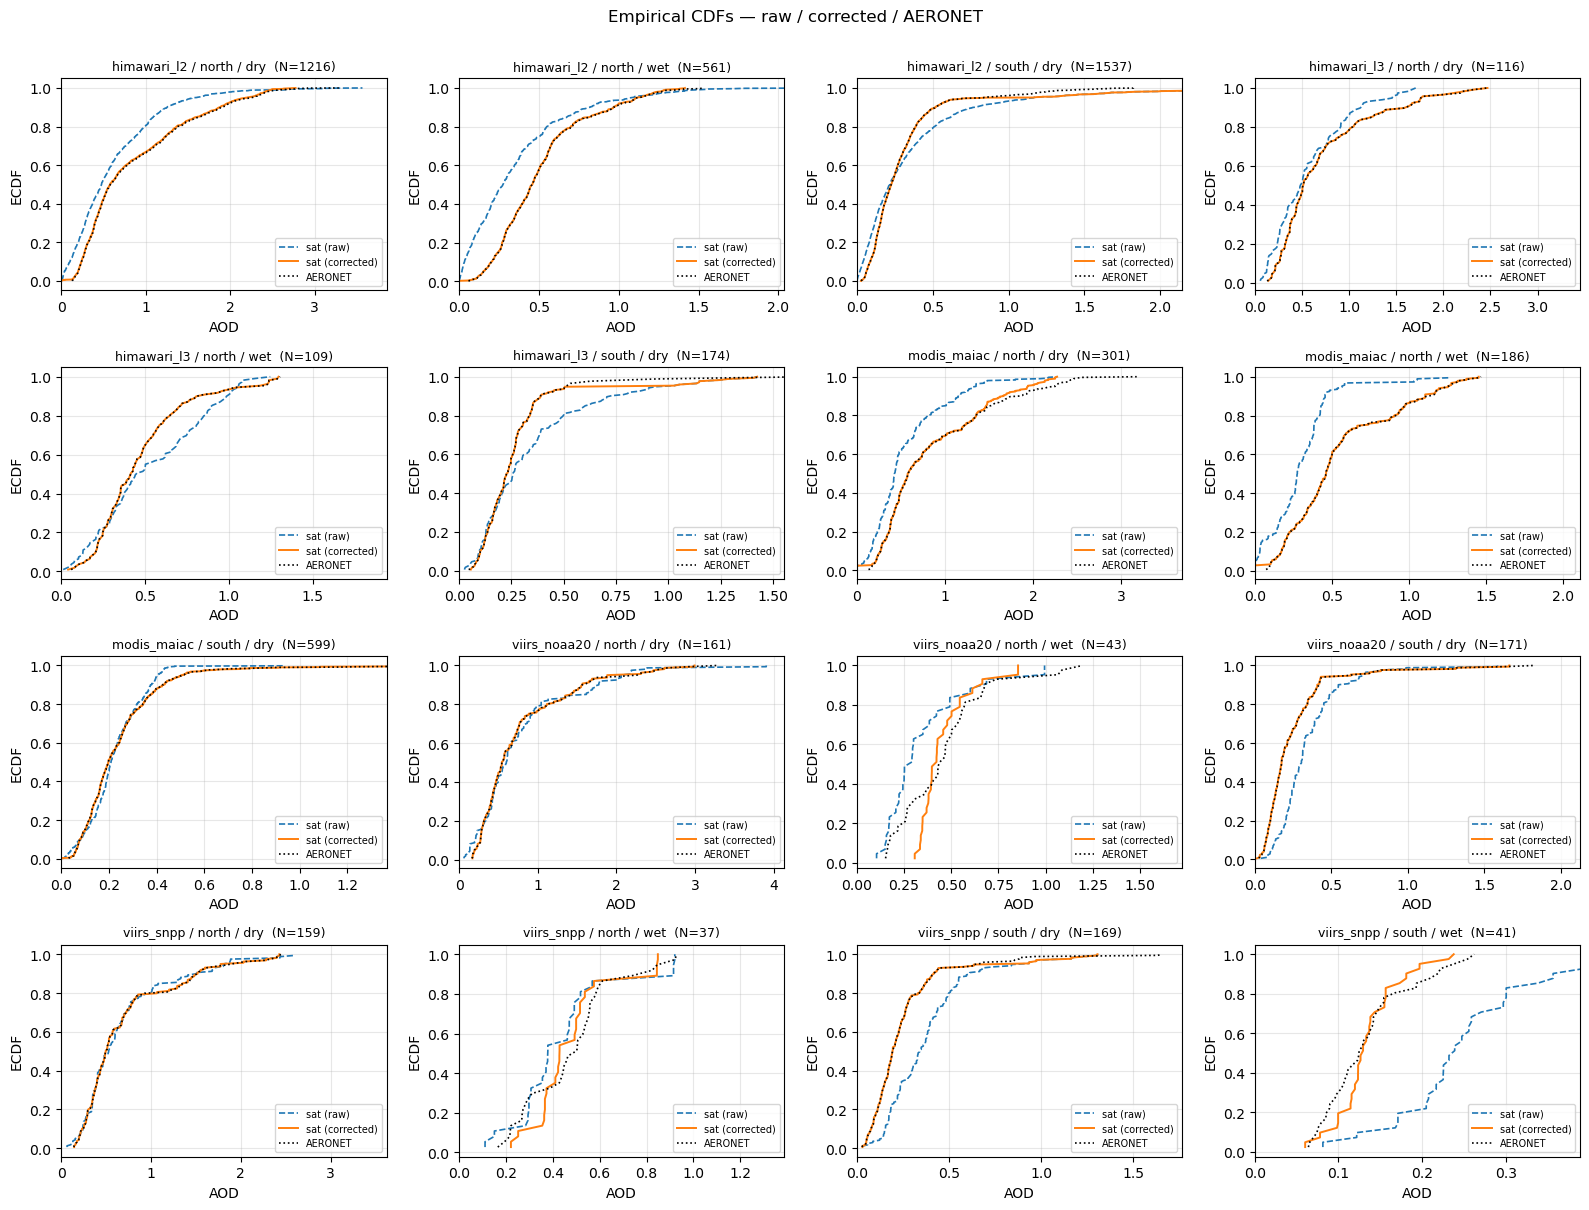

In [6]:
def _ecdf(x):
    x = np.sort(np.asarray(x, dtype=float))
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.array([]), np.array([])
    return x, np.arange(1, len(x) + 1) / len(x)

trained = [k for k, c in sorted(corrections.items()) if c.correction_type != 'none']
n = len(trained)
ncols = 4
nrows = max(1, int(np.ceil(n / ncols)))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

for ax, (s, reg, sea) in zip(axes.flat, trained):
    sub = df[(df['sensor'] == s) & (df['region'] == reg) & (df['season'] == sea)]
    sat = sub['satellite_aod'].values
    cor = sub['sat_corrected'].values
    aer = sub['aeronet_aod'].values
    for arr, label, style in [
        (sat, 'sat (raw)',       dict(color='C0', ls='--', lw=1.2)),
        (cor, 'sat (corrected)', dict(color='C1', ls='-',  lw=1.4)),
        (aer, 'AERONET',         dict(color='k',  ls=':',  lw=1.2)),
    ]:
        x, y = _ecdf(arr)
        if len(x):
            ax.plot(x, y, label=label, **style)
    aer_f = aer[np.isfinite(aer)]
    if len(aer_f):
        ax.set_xlim(0, float(np.percentile(aer_f, 99)) * 1.5)
    ax.set_title(f'{s} / {reg} / {sea}  (N={metrics.loc[(s,reg,sea),"N"]:.0f})',
                 fontsize=9)
    ax.set_xlabel('AOD'); ax.set_ylabel('ECDF')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

for ax in axes.flat[n:]:
    ax.axis('off')
fig.suptitle('Empirical CDFs — raw / corrected / AERONET', y=1.005, fontsize=12)
fig.tight_layout()
plt.show()

## 5. Scatter — raw vs corrected against AERONET

Both raw (blue) and corrected (orange) plotted against AERONET on the same axes
with a 1:1 line. Corrected points should hug the 1:1 line more tightly and
without a systematic offset.

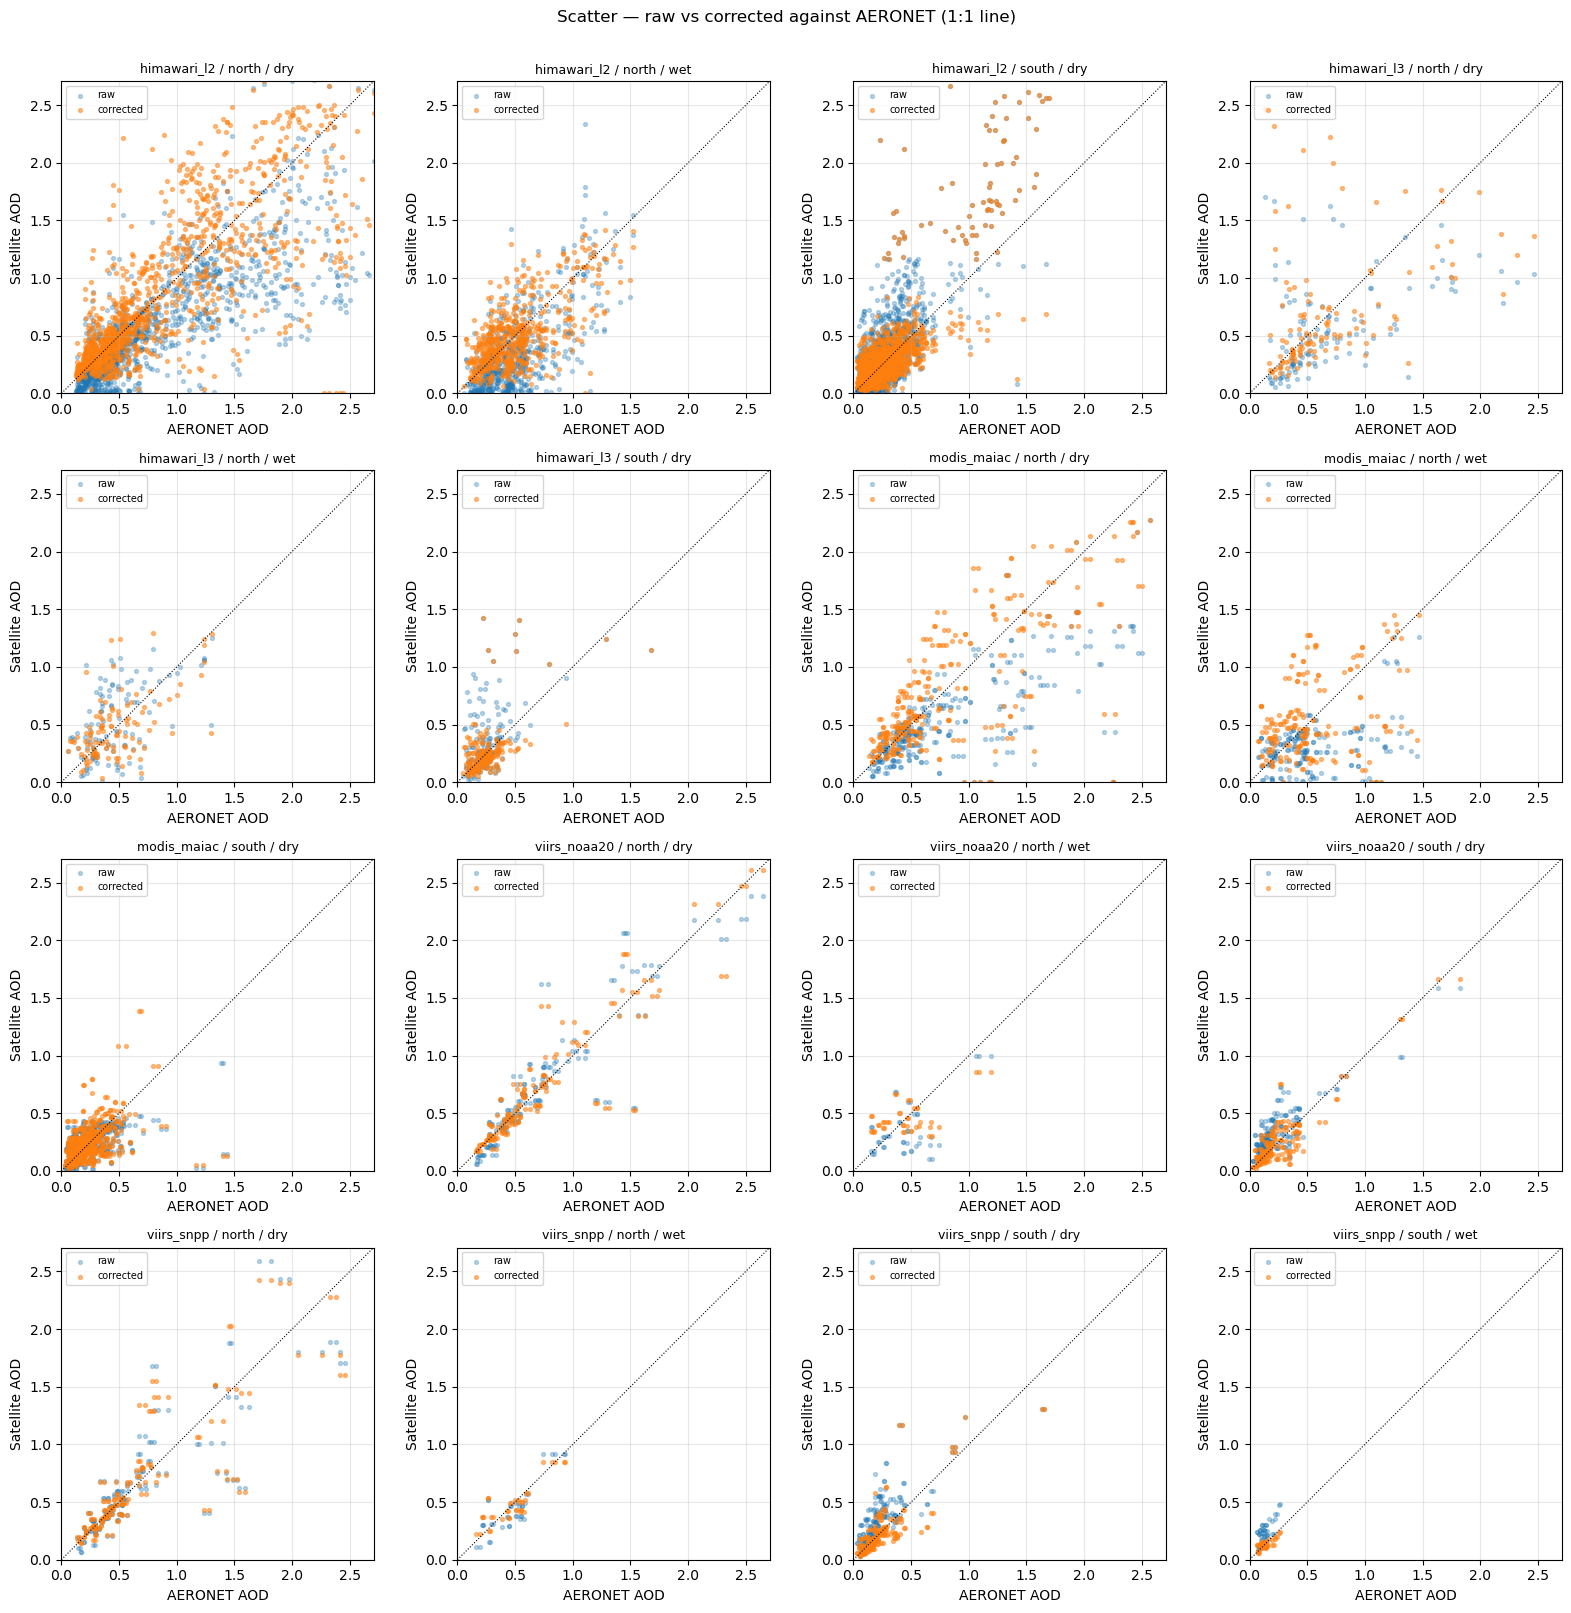

In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), squeeze=False)
lim = float(max(df['aeronet_aod'].quantile(0.995),
                df['satellite_aod'].quantile(0.995))) * 1.1

for ax, (s, reg, sea) in zip(axes.flat, trained):
    sub = df[(df['sensor'] == s) & (df['region'] == reg) & (df['season'] == sea)
             & df['sat_corrected'].notna()]
    ax.scatter(sub['aeronet_aod'], sub['satellite_aod'],
               s=8, alpha=0.3, color='C0', label='raw')
    ax.scatter(sub['aeronet_aod'], sub['sat_corrected'],
               s=8, alpha=0.5, color='C1', label='corrected')
    ax.plot([0, lim], [0, lim], 'k:', lw=0.8)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('AERONET AOD'); ax.set_ylabel('Satellite AOD')
    ax.set_title(f'{s} / {reg} / {sea}', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

for ax in axes.flat[len(trained):]:
    ax.axis('off')
fig.suptitle('Scatter — raw vs corrected against AERONET (1:1 line)',
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()

## 6. Held-out check — CV RMSE vs in-sample RMSE

`rmse_after_cv` is 5-fold out-of-sample, computed in
[`bias_correction._compute_cv_rmse`](bias_correction.py). If `CV / in-sample` is
much greater than 1, the transfer function is fitting noise on the training
quantiles.

In [8]:
cv = (metrics[metrics['type'] != 'none']
        [['type', 'N', 'RMSE_after', 'RMSE_cv', 'CV_infl']]
        .copy())
cv['flag'] = np.where(cv['CV_infl'] > CV_INFLATION_MAX, 'overfit?', 'OK')
cv.sort_values('CV_infl', ascending=False).round(3)

type     N  RMSE_after  RMSE_cv  CV_infl  \
sensor       region season                                                    
viirs_noaa20 south  dry             cdf   171       0.112    0.219    1.954   
             north  dry             cdf   161       0.221    0.260    1.175   
viirs_snpp   north  wet          linear    37       0.100    0.108    1.087   
viirs_noaa20 north  wet          linear    43       0.195    0.212    1.085   
viirs_snpp   north  dry             cdf   159       0.306    0.327    1.069   
himawari_l3  north  wet             cdf   109       0.258    0.275    1.067   
viirs_snpp   south  dry     cdf_clipped   169       0.141    0.149    1.057   
modis_maiac  north  wet             cdf   186       0.403    0.421    1.046   
viirs_snpp   south  wet          linear    41       0.035    0.037    1.045   
himawari_l3  south  dry     cdf_clipped   174       0.205    0.212    1.038   
modis_maiac  north  dry     cdf_clipped   301       0.429    0.436    1.016   
himawari_l2  north  wet             cdf   561       0.240    0.242    1.009   
himawari_l3  north  dry             cdf   116       0.564    0.559    0.991   
himawari_l2  north  dry             cdf  1216       0.422    0.395    0.937   
             south  dry     cdf_clipped  1537       0.233    0.152    0.652   
modis_maiac  south  dry             cdf   599       3.805    0.305    0.080   

                                flag  
sensor       region season            
viirs_noaa20 south  dry     overfit?  
             north  dry           OK  
viirs_snpp   north  wet           OK  
viirs_noaa20 north  wet           OK  
viirs_snpp   north  dry           OK  
himawari_l3  north  wet           OK  
viirs_snpp   south  dry           OK  
modis_maiac  north  wet           OK  
viirs_snpp   south  wet           OK  
himawari_l3  south  dry           OK  
modis_maiac  north  dry           OK  
himawari_l2  north  wet           OK  
himawari_l3  north  dry           OK  
himawari_l2  north  dry           OK  
             south  dry           OK  
modis_maiac  south  dry           OK

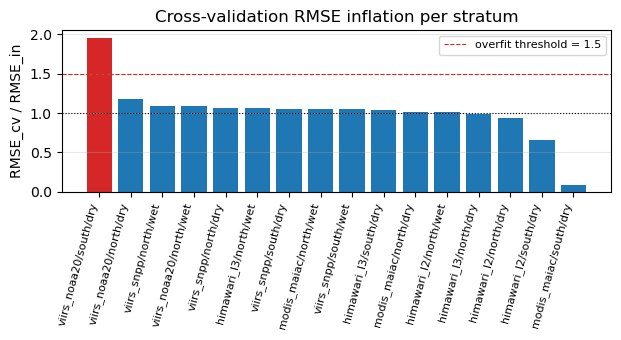

In [9]:
# Bar plot: per-stratum CV inflation
cv_sorted = cv.sort_values('CV_infl', ascending=False)
fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(cv_sorted)), 3.5))
labels = ['/'.join(idx) for idx in cv_sorted.index]
colors = ['C3' if v > CV_INFLATION_MAX else 'C0' for v in cv_sorted['CV_infl']]
ax.bar(range(len(cv_sorted)), cv_sorted['CV_infl'], color=colors)
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.axhline(CV_INFLATION_MAX, color='C3', lw=0.8, ls='--',
           label=f'overfit threshold = {CV_INFLATION_MAX}')
ax.set_xticks(range(len(cv_sorted)))
ax.set_xticklabels(labels, rotation=75, ha='right', fontsize=8)
ax.set_ylabel('RMSE_cv / RMSE_in')
ax.set_title('Cross-validation RMSE inflation per stratum')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## 7. Aggregate sanity (all sensors pooled)

A single headline MBE / RMSE / R over every usable pair, post-correction. Useful
as the one-line answer to "did bias correction help overall?" 

In [10]:
pool = df[df['sat_corrected'].notna()].copy()
sat = pool['satellite_aod'].values.astype(float)
cor = pool['sat_corrected'].values.astype(float)
aer = pool['aeronet_aod'].values.astype(float)
m = np.isfinite(sat) & np.isfinite(aer) & np.isfinite(cor)
sat, cor, aer = sat[m], cor[m], aer[m]

def _summ(x, y):
    return {
        'N':    len(x),
        'MBE':  float(np.mean(x - y)),
        'RMSE': float(np.sqrt(np.mean((x - y) ** 2))),
        'R':    _r(x, y),
        'rho':  _rho(x, y),
    }

print('Pooled across all sensors / regions / seasons (corrected strata only)')
print('-' * 64)
print(f'  Before: {_summ(sat, aer)}')
print(f'  After : {_summ(cor, aer)}')

Pooled across all sensors / regions / seasons (corrected strata only)
----------------------------------------------------------------
  Before: {'N': 6161, 'MBE': -0.05187750047917021, 'RMSE': 0.33302789758676954, 'R': 0.7401034919713769, 'rho': 0.6551797089788535}
  After : {'N': 6161, 'MBE': 0.03665755975328097, 'RMSE': 1.2230261422386495, 'R': 0.3340252509001119, 'rho': 0.7557441490462307}
